#Mini-projeto MLP: Titanic Machine Learning from Disaster

**Equipe:**
* Andreywid Yago Lima de Souza
* Artur Vinícius Pereira Fernandes
* Felipe Mateus Falcão Barreto
* João Pedro Mafaldo de Paula
* Matheus Ayres dos Santos


### **Metadados da Base**

**Descrição:**
Esta base de dados é parte da competição "Titanic: Machine Learning from Disaster" da plataforma Kaggle. Ela contém dados demográficos e de viagem de 891 passageiros do RMS Titanic. O objetivo é utilizar esses atributos para construir um modelo de machine learning capaz de prever se um passageiro sobreviveu ou não ao naufrágio.

**Dicionário de Dados**
* **PassengerId**: Um identificador único para cada passageiro.
* **Survived**: A variável alvo que indica se o passageiro sobreviveu (1 = Sim; 0 = Não).
* **Pclass**: A classe socioeconômica da passagem (1 = 1ª Classe; 2 = 2ª Classe; 3 = 3ª Classe).
* **Name**: O nome do passageiro.
* **Sex**: O sexo do passageiro ('male' ou 'female').
* **Age**: A idade do passageiro em anos.
* **SibSp**: O número de irmãos e/ou cônjuges do passageiro a bordo.
* **Parch**: O número de pais e/ou filhos do passageiro a bordo.
* **Ticket**: O número do bilhete da passagem.
* **Fare**: A tarifa paga pela passagem.
* **Cabin**: O número da cabine do passageiro.
* **Embarked**: O porto de embarque (C = Cherbourg; Q = Queenstown; S = Southampton).

# Importação de bibliotecas e base

In [ ]:
# Importação de Bibliotecas Essenciais
import sklearn as skl
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

import pandas as pd
import os
import zipfile
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sea
import seaborn as sns
import numpy as np
from functools import partial

!pip install optuna
import optuna

# Montagem do Drive
drive.mount("/content/drive", force_remount=True)
set_of_dfs = {} # Utilizado para validar o impacto de certas alterações, tupla de teste e treino (df_treino, df_test)

# carregamento da base
df_train = pd.read_csv("/content/drive/MyDrive/projetosML/dataset/train.csv")
df_test = pd.read_csv("/content/drive/MyDrive/projetosML/dataset/test.csv") # Teste para colocar no Kaggle, a saida no Kaggle
# df_test_survived = pd.read_csv("/content/drive/MyDrive/projetosML/dataset/gender_submission.csv") #Modelo de saida, como ele espera a resposta no Kaggle

print(f"Shape df_train: {df_train.shape}")
print(f"Shape df_test: {df_test.shape}")
#print(f"Shape df_test_survived: {df_test_survived.shape}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.0/247.0 kB 10.8 MB/s eta 0:00:00
Mounted at /content/drive
Shape df_train: (891, 12)
Shape df_test: (418, 11)


## Verificação de tipos

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Análise Exploratória

## Análise Univariada

### Variáveis Numéricas (Age e Fare)


In [ ]:
print(df_train[['Age', 'Fare']].describe())

              Age        Fare
count  714.000000  891.000000
mean    29.699118   32.204208
std     14.526497   49.693429
min      0.420000    0.000000
25%     20.125000    7.910400
50%     28.000000   14.454200
75%     38.000000   31.000000
max     80.000000  512.329200


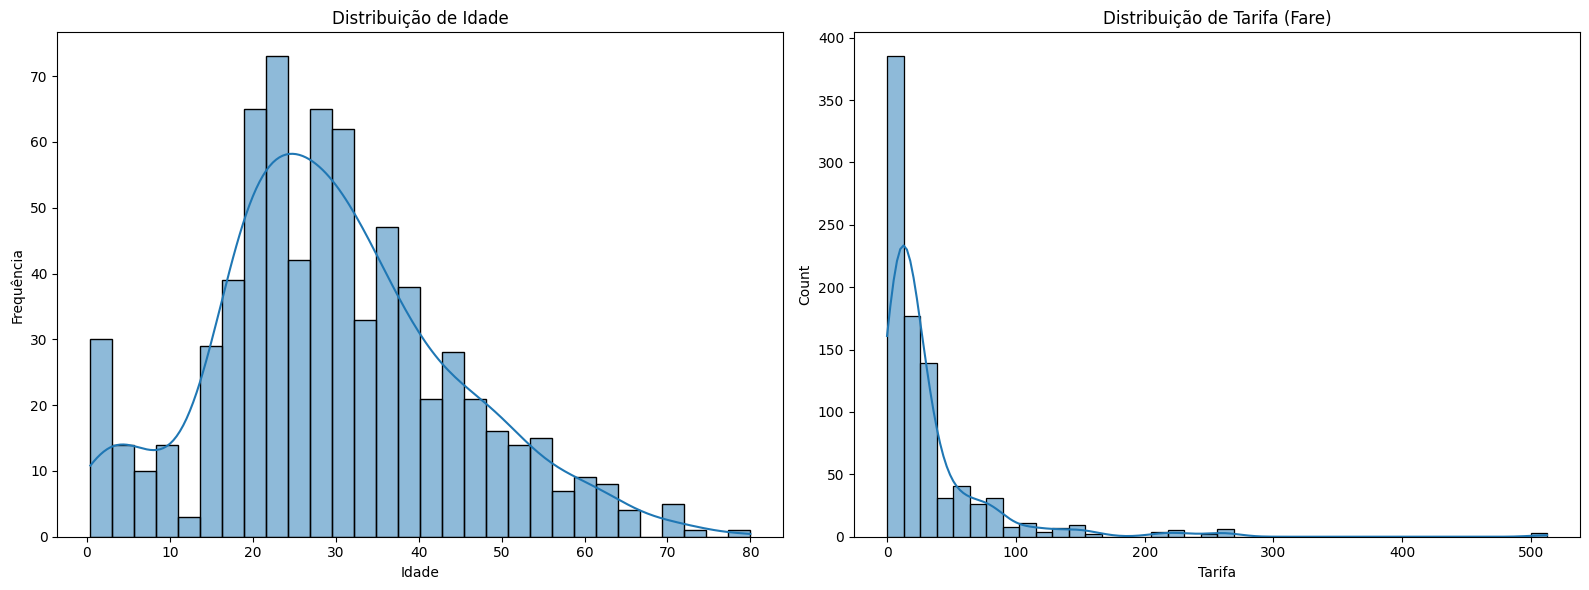

In [ ]:
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)

sns.histplot(df_train['Age'].dropna(), kde=True, bins=30)
plt.title('Distribuição de Idade')
plt.xlabel('Idade')
plt.ylabel('Frequência')

plt.subplot(1, 2, 2)
sns.histplot(df_train['Fare'], kde=True, bins=40)
plt.title('Distribuição de Tarifa (Fare)')
plt.xlabel('Tarifa')

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Boxplot de Tarifa')

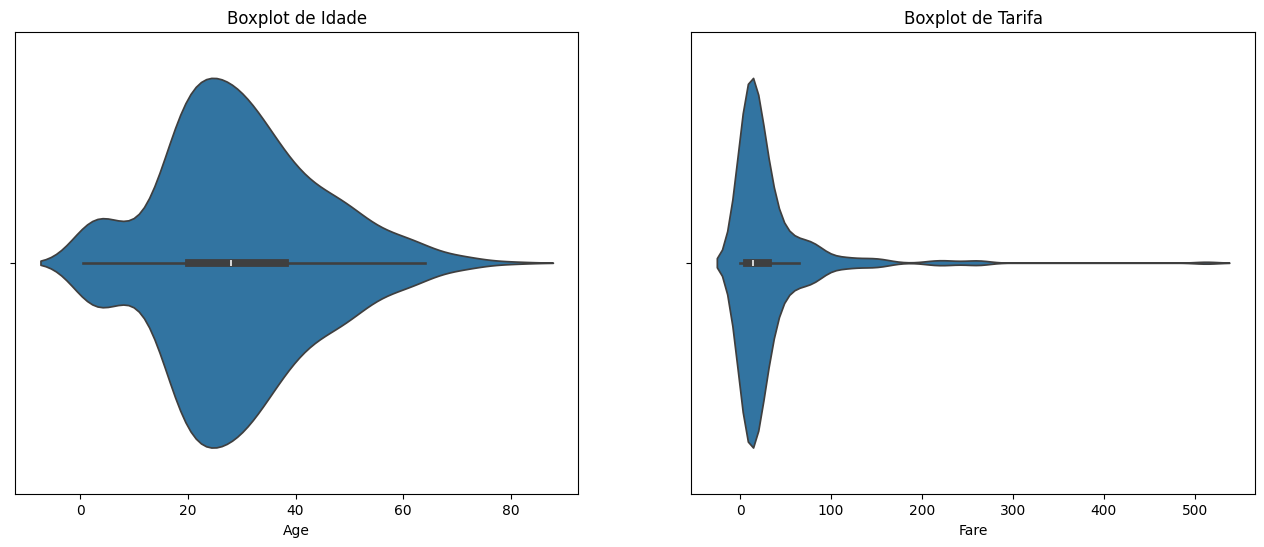

In [ ]:
plt.figure(figsize=(16, 6))

# Boxplot da Idade
plt.subplot(1, 2, 1)
sns.violinplot(x=df_train['Age'])
plt.title('Boxplot de Idade')

# Boxplot da Tarifa
plt.subplot(1, 2, 2)
sns.violinplot(x=df_train['Fare'])
plt.title('Boxplot de Tarifa')

### Variáveis Categóricas

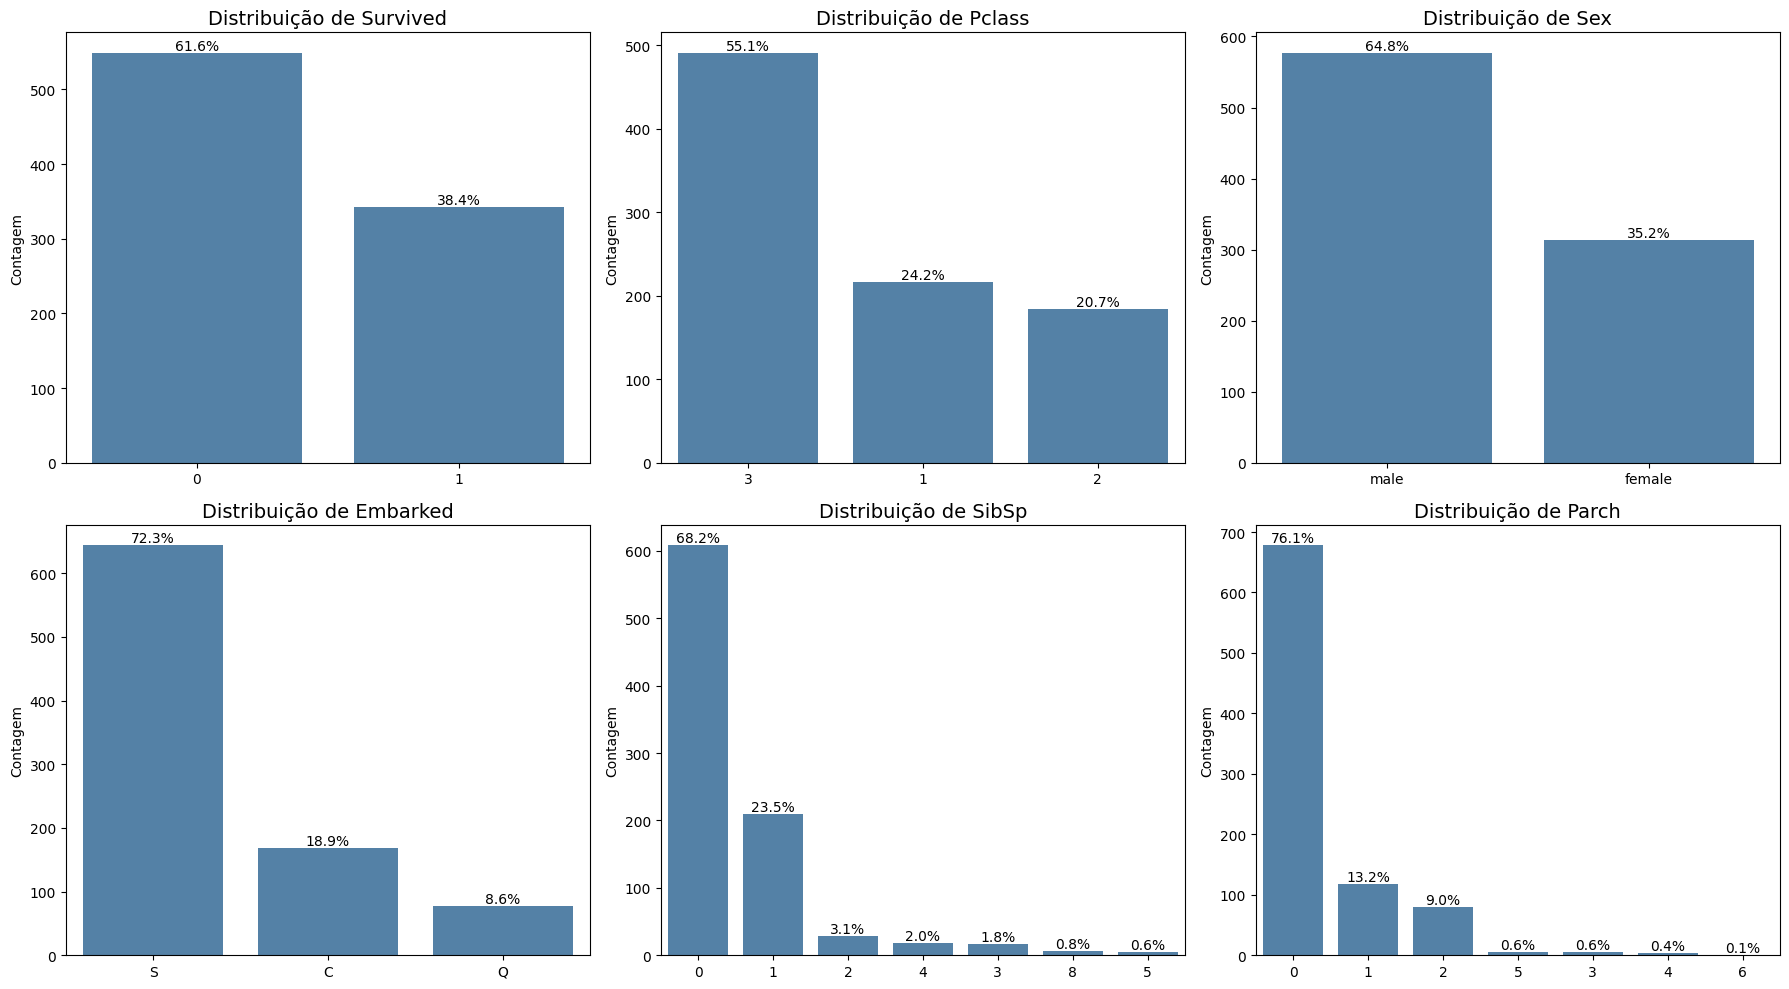

In [ ]:
cols_cate = ['Survived', 'Pclass', 'Sex', 'Embarked', 'SibSp', 'Parch']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cols_cate):
    sns.countplot(
        x=col,
        data=df_train,
        ax=axes[i],
        color='steelblue',
        order=df_train[col].value_counts().index
    )
    axes[i].set_title(f'Distribuição de {col}', fontsize=14)
    axes[i].set_ylabel('Contagem')
    axes[i].set_xlabel('')

    for p in axes[i].patches:
        percentage = f'{100 * p.get_height() / len(df_train):.1f}%'
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        axes[i].annotate(percentage, (x, y), ha='center', va='bottom')

plt.tight_layout()
plt.show()

## Análise bivariada

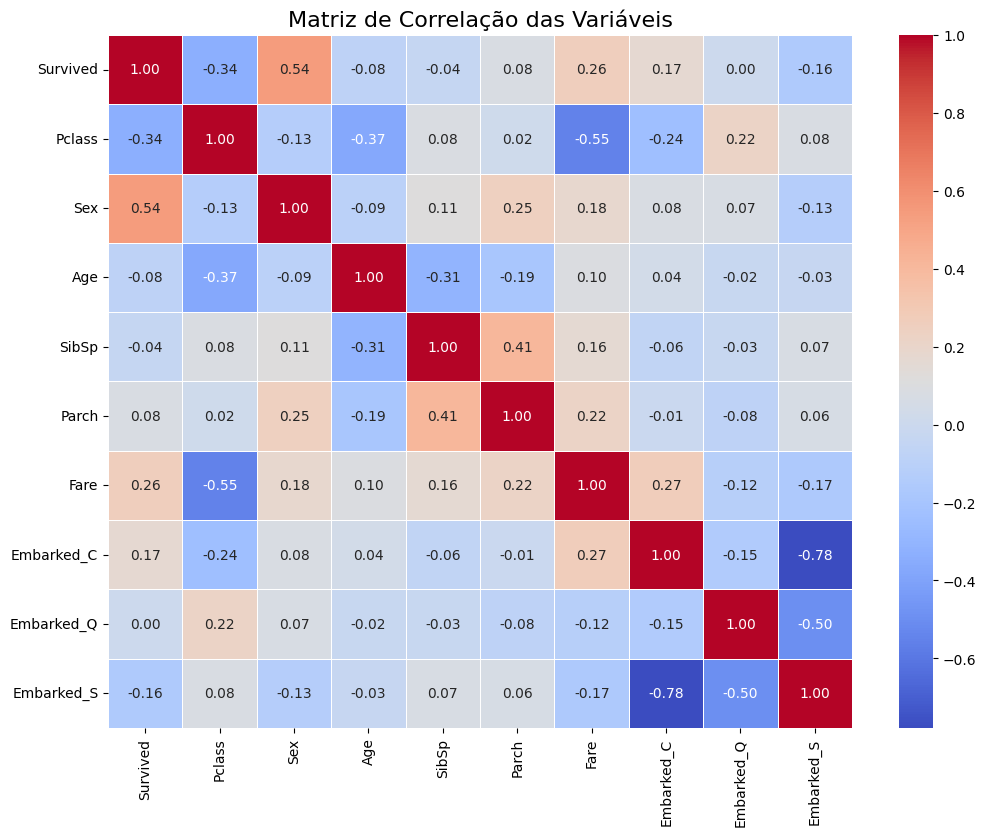

In [ ]:
df_corr = df_train.copy()

# colunas que não têm valor para a correlação.
df_corr.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], inplace=True)


df_corr['Sex'] = df_corr['Sex'].map({'male': 0, 'female': 1})
# One-Hot Encoding para 'Embarked'
df_corr = pd.get_dummies(df_corr, columns=['Embarked'], prefix='Embarked', drop_first=False)

correlation_matrix = df_corr.corr()

# heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=.5
)
plt.title('Matriz de Correlação das Variáveis', fontsize=16)
plt.show()

### Variáveis Numéricas vs Sobrevivência

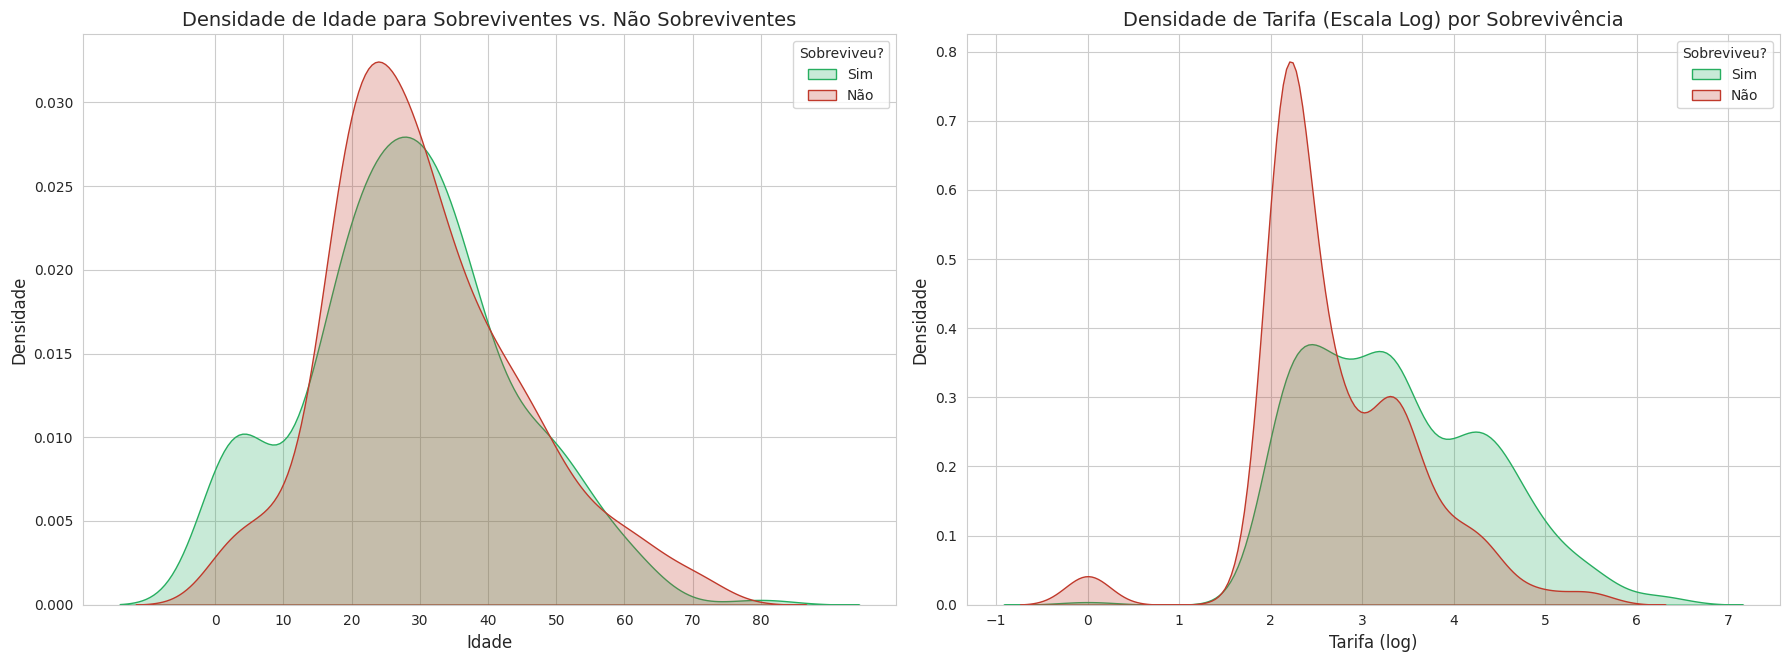

In [ ]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sobrevivencia_palette = {0: "#c0392b", 1: "#27ae60"}

# Gráfico de Densidade para Idade
sns.kdeplot(
    data=df_train,
    x='Age',
    hue='Survived',
    ax=axes[0],
    palette=sobrevivencia_palette,
    fill=True,
    common_norm=False
)
axes[0].set_title('Densidade de Idade para Sobreviventes vs. Não Sobreviventes', fontsize=14)
axes[0].set_xlabel('Idade', fontsize=12)
axes[0].set_ylabel('Densidade', fontsize=12)
axes[0].legend(title='Sobreviveu?', labels=['Sim', 'Não'])

axes[0].set_xticks(np.arange(0, 90, 10))

# Gráfico de Densidade para Tarifa em Escala Logarítmica
# Aplicamos (log(1+x)) para tratar a assimetria e os valores zero da tarifa
df_train['Fare_log'] = np.log1p(df_train['Fare'])

sns.kdeplot(
    data=df_train,
    x='Fare_log',
    hue='Survived',
    ax=axes[1],
    palette=sobrevivencia_palette,
    fill=True,
    common_norm=False
)
axes[1].set_title('Densidade de Tarifa (Escala Log) por Sobrevivência', fontsize=14)
axes[1].set_xlabel('Tarifa (log)', fontsize=12)
axes[1].set_ylabel('Densidade', fontsize=12)
axes[1].legend(title='Sobreviveu?', labels=['Sim', 'Não'])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

df_train.drop(columns=['Fare_log'], inplace=True)

### Variáveis Categóricas vs Sobrevivência

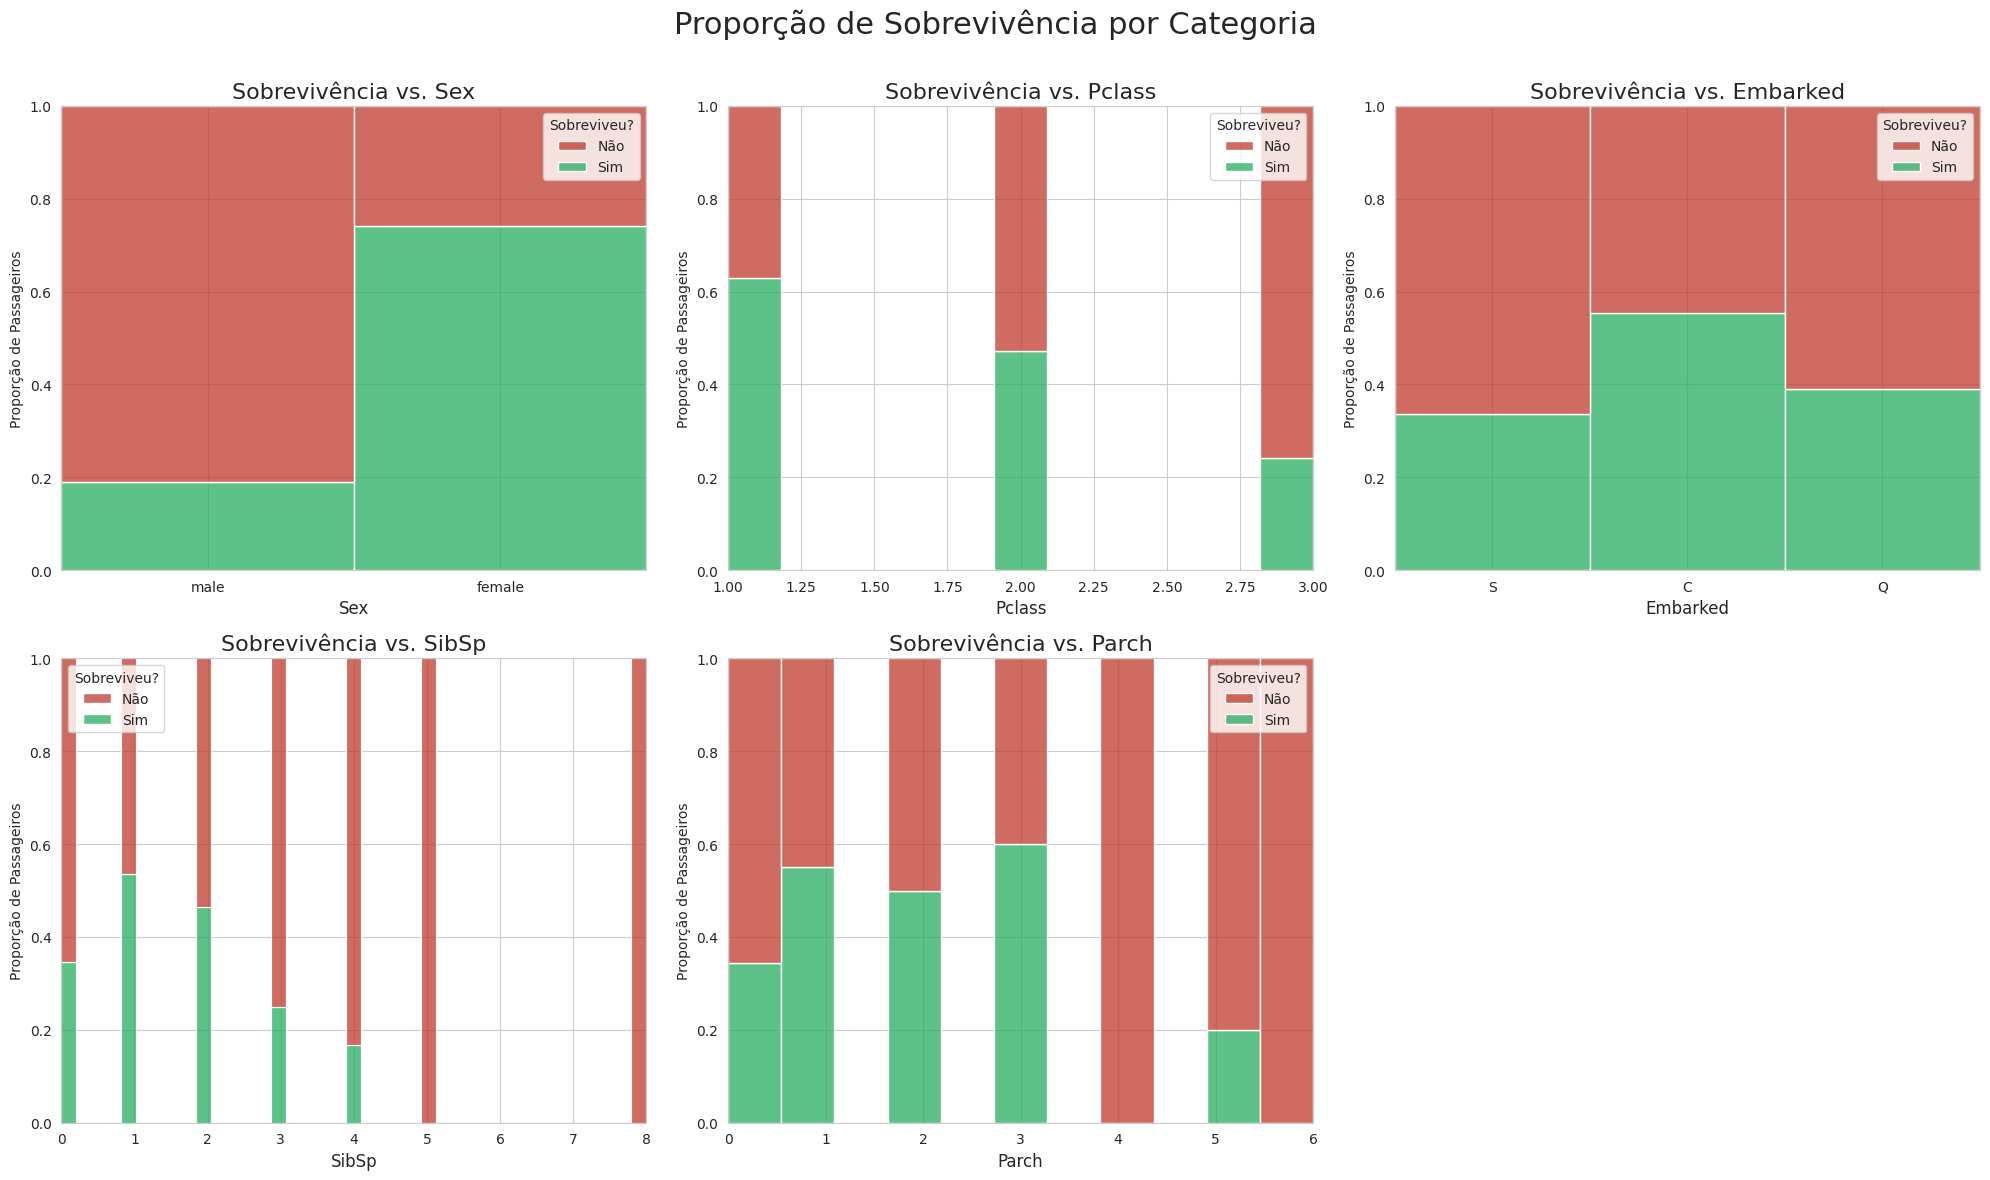

In [ ]:
sns.set_style("whitegrid")

cat_cols_bivariate = ['Sex', 'Pclass', 'Embarked', 'SibSp', 'Parch']

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Proporção de Sobrevivência por Categoria', fontsize=22)

axes = axes.flatten()

sobrevivencia_palette = {0: "#c0392b", 1: "#27ae60"}

for i, col in enumerate(cat_cols_bivariate):
    sns.histplot(
        data=df_train,
        x=col,
        hue='Survived',
        multiple='fill',
        palette=sobrevivencia_palette,
        ax=axes[i],

    )
    axes[i].set_title(f'Sobrevivência vs. {col}', fontsize=16)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Proporção de Passageiros')

    legend = axes[i].get_legend()
    if legend:
        legend.set_title('Sobreviveu?')
        new_labels = ['Não', 'Sim']
        for t, l in zip(legend.texts, new_labels):
            t.set_text(l)

axes[5].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

#Pré-Processamento e Preparação dos Dados.

In [ ]:
# Separando as features (X) da variável alvo (y)
X = df_train.drop('Survived', axis=1)
y = df_train['Survived']

# Primeira divisão: 50% para Treino
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.50,
    random_state=42,
    stratify=y
)
# Segunda divisão: 25% para Validação e 25% para Teste.
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

total_len = len(df_train)
print(f"conjunto de Treino: {len(X_train)}")
print(f"conjunto de Validação: {len(X_val)}")
print(f"conjunto de Teste: {len(X_test)}")

conjunto de Treino: 445
conjunto de Validação: 223
conjunto de Teste: 223


## Tratamento de valores ausentes

In [ ]:
print("Nulos em X_train:\n", X_train.isnull().sum())
print("\nNulos em X_val:\n", X_val.isnull().sum())
print("\nNulos em X_test:\n", X_test.isnull().sum())

Nulos em X_train:
 PassengerId      0
Pclass           0
Name             0
Sex              0
Age             91
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          346
Embarked         1
dtype: int64

Nulos em X_val:
 PassengerId      0
Pclass           0
Name             0
Sex              0
Age             37
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          173
Embarked         0
dtype: int64

Nulos em X_test:
 PassengerId      0
Pclass           0
Name             0
Sex              0
Age             49
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          168
Embarked         1
dtype: int64


### Tratamento da coluna 'Cabin'

In [ ]:
# Transformando em "Has_Cabin"
Xs = [X_train, X_test, X_val]

for i, X in enumerate(Xs):
    not_null_value = X["Cabin"].notna()
    cabins = X["Cabin"].copy()
    cabins[not_null_value] = 1
    cabins[~not_null_value] = 0

    X["Cabin"] = cabins
    X = X.rename(columns = {"Cabin":"Has_Cabin"})
    #X só cria um temp para o valor de Xs, precisa dessa linha para atualizar
    Xs[i] = X
X_train, X_test, X_val = Xs

### Tratamento da coluna 'Age'

In [ ]:
# Calcula a mediana por sexo usando apenas X_train
age_median_by_sex = X_train.groupby('Sex')['Age'].median()

print(age_median_by_sex)

Sex
female    29.0
male      30.0
Name: Age, dtype: float64


In [ ]:
# Preenche os valores nulos usando a mediana de X_train por sexo
X_train['Age'] = X_train['Age'].fillna(X_train['Sex'].map(age_median_by_sex))
X_val['Age'] = X_val['Age'].fillna(X_val['Sex'].map(age_median_by_sex))
X_test['Age'] = X_test['Age'].fillna(X_test['Sex'].map(age_median_by_sex))

### Tratamento da coluna 'Embarked'


In [ ]:
embarked_mode = X_train['Embarked'].mode()[0]
print(f"A moda de embarque de X_train: '{embarked_mode}'")

A moda de embarque de X_train: 'S'


In [ ]:
# Aplicando a moda
X_train['Embarked'] = X_train['Embarked'].fillna(embarked_mode)
X_val['Embarked'] = X_val['Embarked'].fillna(embarked_mode)
X_test['Embarked'] = X_test['Embarked'].fillna(embarked_mode)

## Codificação de Variáveis Categóricas

In [ ]:
# removendo colunas muitos valores únicos
X_train.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)
X_val.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)
X_test.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)

In [ ]:
# Mapeamento Binário da coluna 'Sex'
sex_map = {'male': 0, 'female': 1}

X_train['Sex'] = X_train['Sex'].map(sex_map)
X_val['Sex'] = X_val['Sex'].map(sex_map)
X_test['Sex'] = X_test['Sex'].map(sex_map)

In [ ]:
# One-Hot Encoding da coluna 'Embarked'
X_train = pd.get_dummies(X_train, columns=['Embarked'], prefix='Embarked', dtype=int)
X_val = pd.get_dummies(X_val, columns=['Embarked'], prefix='Embarked', dtype=int)
X_test = pd.get_dummies(X_test, columns=['Embarked'], prefix='Embarked', dtype=int)

In [ ]:
# Verificando nossa train
print(X_train.info())
print(X_train.head())

<class 'pandas.core.frame.DataFrame'>
Index: 445 entries, 652 to 28
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pclass      445 non-null    int64  
 1   Sex         445 non-null    int64  
 2   Age         445 non-null    float64
 3   SibSp       445 non-null    int64  
 4   Parch       445 non-null    int64  
 5   Fare        445 non-null    float64
 6   Has_Cabin   445 non-null    object 
 7   Embarked_C  445 non-null    int64  
 8   Embarked_Q  445 non-null    int64  
 9   Embarked_S  445 non-null    int64  
dtypes: float64(2), int64(7), object(1)
memory usage: 38.2+ KB
None
     Pclass  Sex   Age  SibSp  Parch      Fare Has_Cabin  Embarked_C  \
652       3    0  21.0      0      0    8.4333         0           0   
550       1    0  17.0      0      2  110.8833         1           1   
254       3    1  41.0      0      2   20.2125         0           0   
24        3    1   8.0      3      1   21.0750     

## Criação de coluna sobre quantidade de parentes à bordo

In [ ]:
Xs = [X_train, X_test, X_val]

for i, X in enumerate(Xs):
    family_size = X["SibSp"] + X["Parch"] + 1
    X["Relatives"] = family_size
    X = X.drop(columns = ["SibSp", "Parch"])
    Xs[i] = X

X_train, X_test, X_val = Xs


In [ ]:
print(X_train.columns)

Index(['Pclass', 'Sex', 'Age', 'Fare', 'Has_Cabin', 'Embarked_C', 'Embarked_Q',
       'Embarked_S', 'Relatives'],
      dtype='object')


## Normalização dos Dados

In [ ]:
# Inicialização
scaler = MinMaxScaler()

# Aprendendo a escala os dados de treino
scaler.fit(X_train)

# Aplicando a transformação
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns, index=X_val.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

In [ ]:
# Checando a escala dos dados
print(X_train_scaled.head())
print(X_train_scaled.describe().loc[['min', 'max']])

     Pclass  Sex       Age      Fare  Has_Cabin  Embarked_C  Embarked_Q  \
652     1.0  0.0  0.258608  0.016461        0.0         0.0         0.0   
550     0.0  0.0  0.208344  0.216430        1.0         1.0         0.0   
254     1.0  1.0  0.509927  0.039452        0.0         0.0         0.0   
24      1.0  1.0  0.095250  0.041136        0.0         0.0         0.0   
434     0.0  0.0  0.623021  0.109110        1.0         0.0         0.0   

     Embarked_S  Relatives  
652         1.0        0.0  
550         0.0        0.2  
254         1.0        0.2  
24          1.0        0.4  
434         1.0        0.1  
     Pclass  Sex  Age  Fare  Has_Cabin  Embarked_C  Embarked_Q  Embarked_S  \
min     0.0  0.0  0.0   0.0        0.0         0.0         0.0         0.0   
max     1.0  1.0  1.0   1.0        1.0         1.0         1.0         1.0   

     Relatives  
min        0.0  
max        1.0  


# Modelagem e Avaliação

## Modelo 1: Rede Neural (MLP)

### Experimento 0

In [ ]:
# Instanciando o Modelo
# hidden_layer_sizes=(100,): Uma camada escondida com 100 neurônios.
# max_iter=500:
# random_state=42:
mlp_base = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)

In [ ]:
# Treinando o Modelo
mlp_base.fit(X_train_scaled, y_train)

MLPClassifier(max_iter=500, random_state=42)

In [ ]:
# Fazendo previsões nos dados de treino
y_pred_train = mlp_base.predict(X_train_scaled)
# Fazendo previsões nos dados de validação
y_pred_val = mlp_base.predict(X_val_scaled)

In [ ]:
accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_val = accuracy_score(y_val, y_pred_val)

print(f"Acurácia no conjunto de TREINO: {accuracy_train * 100:.2f}%")
print(f"Acurácia no conjunto de VALIDAÇÃO: {accuracy_val * 100:.2f}%")

Acurácia no conjunto de TREINO: 82.70%
Acurácia no conjunto de VALIDAÇÃO: 82.96%


### Experimento 1

In [ ]:
# Rede com 10 neurônios

mlp_exp1 = MLPClassifier(
    hidden_layer_sizes=(10,),
    max_iter=500,
    random_state=42
)

mlp_exp1.fit(X_train_scaled, y_train)

y_pred_train_exp1 = mlp_exp1.predict(X_train_scaled)
y_pred_val_exp1 = mlp_exp1.predict(X_val_scaled)
acc_train_exp1 = accuracy_score(y_train, y_pred_train_exp1)
acc_val_exp1 = accuracy_score(y_val, y_pred_val_exp1)

print(f"Acurácia no TREINO: {acc_train_exp1 * 100:.2f}%")
print(f"Acurácia na VALIDAÇÃO: {acc_val_exp1 * 100:.2f}%")

Acurácia no TREINO: 78.65%
Acurácia na VALIDAÇÃO: 81.61%


### Experimento 2

In [ ]:
# Rede com a activation='tanh'

mlp_exp1 = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='tanh',
    max_iter=500,
    random_state=42
)

mlp_exp1.fit(X_train_scaled, y_train)

y_pred_train_exp1 = mlp_exp1.predict(X_train_scaled)
y_pred_val_exp1 = mlp_exp1.predict(X_val_scaled)
acc_train_exp1 = accuracy_score(y_train, y_pred_train_exp1)
acc_val_exp1 = accuracy_score(y_val, y_pred_val_exp1)

print(f"Acurácia no TREINO: {acc_train_exp1 * 100:.2f}%")
print(f"Acurácia na VALIDAÇÃO: {acc_val_exp1 * 100:.2f}%")

Acurácia no TREINO: 79.55%
Acurácia na VALIDAÇÃO: 82.51%


### Experimento 3

In [ ]:
# Uma rede menos neurônios por camada

mlp_exp1 = MLPClassifier(
    hidden_layer_sizes=(50,25),
    max_iter=500,
    random_state=42
)

mlp_exp1.fit(X_train_scaled, y_train)

y_pred_train_exp1 = mlp_exp1.predict(X_train_scaled)
y_pred_val_exp1 = mlp_exp1.predict(X_val_scaled)
acc_train_exp1 = accuracy_score(y_train, y_pred_train_exp1)
acc_val_exp1 = accuracy_score(y_val, y_pred_val_exp1)

print(f"Acurácia no TREINO: {acc_train_exp1 * 100:.2f}%")
print(f"Acurácia na VALIDAÇÃO: {acc_val_exp1 * 100:.2f}%")

Acurácia no TREINO: 84.04%
Acurácia na VALIDAÇÃO: 87.44%


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


### Experimento 4

In [ ]:
# Uma rede menos neurônios por camada

mlp_experimento = MLPClassifier(

    hidden_layer_sizes=(10,),
    activation='relu',

    solver='sgd',
    alpha=1,
    learning_rate_init=1,

    max_iter=500,
    batch_size='auto',
    shuffle=True,

    early_stopping=False,
    validation_fraction=0.1,
    n_iter_no_change=10,

    random_state=42,
    verbose=False
)


mlp_exp1.fit(X_train_scaled, y_train)

y_pred_train_exp1 = mlp_exp1.predict(X_train_scaled)
y_pred_val_exp1 = mlp_exp1.predict(X_val_scaled)
acc_train_exp1 = accuracy_score(y_train, y_pred_train_exp1)
acc_val_exp1 = accuracy_score(y_val, y_pred_val_exp1)

print(f"Acurácia no TREINO: {acc_train_exp1 * 100:.2f}%")
print(f"Acurácia na VALIDAÇÃO: {acc_val_exp1 * 100:.2f}%")

Acurácia no TREINO: 84.04%
Acurácia na VALIDAÇÃO: 87.44%


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


### Grid Search

In [ ]:
X_train_val = pd.concat([X_train_scaled, X_val_scaled])
y_train_val = pd.concat([y_train, y_val])

param_grid = {
    'hidden_layer_sizes': [(100,), (50, 25)],
    'activation': ['relu'],
    'solver': ['adam', 'sgd'],
    'alpha': [0.0001, 0.01]
}

grid_search = GridSearchCV(
    MLPClassifier(max_iter=1000, random_state=42),
    param_grid,
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_val, y_train_val)

print(grid_search.best_params_)
print(f"\nMelhor acurácia de validação cruzada: {grid_search.best_score_ * 100:.2f}%")
best_mlp_model = grid_search.best_estimator_

Fitting 3 folds for each of 8 candidates, totalling 24 fits
{'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (100,), 'solver': 'adam'}

Melhor acurácia de validação cruzada: 81.74%


### Optuna

In [ ]:
def objective(trial):
    hidden_layer_options = {
        '100': (100,),
        '50_25': (50, 25),
        '100_50': (100, 50)
    }

    hidden_layer_key = trial.suggest_categorical('hidden_layer_sizes', list(hidden_layer_options.keys()))
    hidden_layers = hidden_layer_options[hidden_layer_key]

    params = {
        'hidden_layer_sizes': hidden_layers,
        'activation': trial.suggest_categorical('activation', ['relu', 'tanh']),
        'solver': 'adam',
        'alpha': trial.suggest_float('alpha', 1e-5, 1e-1, log=True),
        'learning_rate_init': trial.suggest_float('learning_rate_init', 1e-4, 1e-2, log=True),
    }

    model = MLPClassifier(max_iter=1000, random_state=42, **params)
    scores = cross_val_score(model, X_train_val, y_train_val, cv=3, n_jobs=-1)

    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, timeout=25, show_progress_bar=True)

print("\nNúmero de testes realizados:", len(study.trials))

best_trial = study.best_trial
print("\nMelhor resultado:")
print(f"  Acurácia média: {best_trial.value * 100:.2f}%")
print("  Hiperparâmetros ideais:")
for key, value in best_trial.params.items():
    print(f"    {key}: {value}")

[I 2025-07-25 22:26:25,606] A new study created in memory with name: no-name-0fdbaacd-9828-463e-90aa-ac7efc43de5e


   0%|          | 00:00/00:25

[I 2025-07-25 22:26:28,828] Trial 0 finished with value: 0.7949541469720843 and parameters: {'hidden_layer_sizes': '100_50', 'activation': 'tanh', 'alpha': 0.09040061160403423, 'learning_rate_init': 0.0033392338493699277}. Best is trial 0 with value: 0.7949541469720843.
[I 2025-07-25 22:26:29,698] Trial 1 finished with value: 0.7994384519048197 and parameters: {'hidden_layer_sizes': '100', 'activation': 'tanh', 'alpha': 0.0003032628039229534, 'learning_rate_init': 0.008416652672888367}. Best is trial 1 with value: 0.7994384519048197.
[I 2025-07-25 22:26:33,569] Trial 2 finished with value: 0.8069190266499683 and parameters: {'hidden_layer_sizes': '100_50', 'activation': 'relu', 'alpha': 8.207517413341899e-05, 'learning_rate_init': 0.00043370646772167575}. Best is trial 2 with value: 0.8069190266499683.
[I 2025-07-25 22:26:36,447] Trial 3 finished with value: 0.8159145692777979 and parameters: {'hidden_layer_sizes': '50_25', 'activation': 'relu', 'alpha': 0.0018781608421320026, 'learnin

### Avaliação Final do Modelo MLP no Conjunto de Teste

In [ ]:
best_params = {
    'hidden_layer_sizes': (100,),
    'activation': 'relu',
    'solver': 'adam',
    'alpha': 0.0023346947419990707,
    'learning_rate_init': 0.003910803447734125,
    'max_iter': 1000,
    'random_state': 42
}

In [ ]:
# Instanciando
mlp_final = MLPClassifier(**best_params)

In [ ]:
X_train_val = pd.concat([X_train_scaled, X_val_scaled])
y_train_val = pd.concat([y_train, y_val])

# Treinando
mlp_final.fit(X_train_val, y_train_val)

MLPClassifier(alpha=0.0023346947419990707,
              learning_rate_init=0.003910803447734125, max_iter=1000,
              random_state=42)

In [ ]:
print("Avaliando o modelo no conjunto de teste")
y_pred_final = mlp_final.predict(X_test_scaled)
final_accuracy = accuracy_score(y_test, y_pred_final)

Avaliando o modelo no conjunto de teste


In [ ]:
print(f"ACURÁCIA FINAL DO PROJETO: {final_accuracy * 100:.2f}%")

ACURÁCIA FINAL DO PROJETO: 77.58%
